### Phase 1: Feature Engineering

In [ ]:
# Load the Cleaned Dataset
import pandas as pd

df = pd.read_csv(r"C:\Users\FireFly\Desktop\potfolio2.0\PORTFOLIO\CUSTOMER_CHURN PREDICTION\data\cleaned_telco_churn.csv")

In [ ]:
#Remove Data Leakage Columns
columns_to_drop = [
    "customerid",
    "churn_label",
    "churn_reason",   # Available only after churn
    "churn_score",    # Remove if generated by another model
    "count"
]

df = df.drop(columns=columns_to_drop, errors="ignore")

In [ ]:
# Create New Features
df["cltv_per_month"] = df["cltv"] / (df["tenure_months"] + 1)

In [4]:
# Convert blanks to NaN, then convert to numeric
df["total_charges"] = pd.to_numeric(df["total_charges"], errors="coerce")
df["total_charges"] = df["total_charges"].fillna(df["total_charges"].median())

In [5]:
df["avg_monthly_spend"] = (
    df["total_charges"] /
    (df["tenure_months"] + 1)
)

In [6]:
df["avg_monthly_spend"] = (
    df["total_charges"] /
    (df["tenure_months"] + 1)
)

In [7]:
services = [
    "phone_service",
    "multiple_lines",
    "online_security",
    "online_backup",
    "device_protection",
    "tech_support",
    "streaming_tv",
    "streaming_movies"
]

df["num_services"] = (
    df[services]
    .apply(lambda row: sum(row == "Yes"), axis=1)
)

In [8]:
median = df["cltv"].median()

df["high_value_customer"] = (
    df["cltv"] > median
).astype(int)

In [9]:
df["tenure_group"] = pd.cut(
    df["tenure_months"],
    bins=[0,12,24,48,72],
    labels=[
        "0-12",
        "13-24",
        "25-48",
        "49-72"
    ]
)

### Phase 2: Build the Preprocessing Pipeline


In [ ]:
#Define Features and Target
X = df.drop(columns=["churn_value"])

y = df["churn_value"]

categorical_features = X.select_dtypes(include="object").columns.tolist()

numerical_features = X.select_dtypes(exclude="object").columns.tolist()

In [ ]:
# Separate Numerical and Categorical Features
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

In [ ]:
# Create Transformers
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

In [ ]:
# Numerical Pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [ ]:
# Categorical Pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [ ]:
# Combine Pipelines
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

### Phase 3: Train and Compare Models

In [ ]:
# Split Data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
X_train.dtypes

country                  object
state                    object
city                     object
zip_code                  int64
lat_long                 object
latitude                float64
longitude               float64
gender                   object
senior_citizen           object
partner                  object
dependents               object
tenure_months             int64
phone_service            object
multiple_lines           object
internet_service         object
online_security          object
online_backup            object
device_protection        object
tech_support             object
streaming_tv             object
streaming_movies         object
contract                 object
paperless_billing        object
payment_method           object
monthly_charges         float64
total_charges           float64
cltv                      int64
cltv_per_month          float64
avg_monthly_spend       float64
num_services              int64
high_value_customer       int64
tenure_g

In [ ]:
# Train Logistic Regression
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
#Train Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
# Train XGBoost
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Compare Models

In [21]:
from sklearn.metrics import classification_report

pred = xgb_pipeline.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1035
           1       0.60      0.53      0.56       374

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.77      0.78      0.78      1409



In [22]:

pred = rf_pipeline.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.65      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [23]:

pred = lr_pipeline.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



### Phase 4: Hyperparameter Tuning

In [24]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0]
}

search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

### Phase 5: Feature Importance

In [25]:
feature_names = (
    best_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    best_model.named_steps["model"]
    .feature_importances_
)

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

print(importance_df.head(15))

                                   Feature  Importance
2825          cat__contract_Month-to-month    0.334599
2805     cat__internet_service_Fiber optic    0.099887
2807               cat__online_security_No    0.089369
2816                  cat__tech_support_No    0.085344
2832  cat__payment_method_Electronic check    0.056388
2797                    cat__dependents_No    0.042448
2827                cat__contract_Two year    0.031037
3                       num__tenure_months    0.028656
2826                cat__contract_One year    0.025190
7                      num__cltv_per_month    0.023121
2824             cat__streaming_movies_Yes    0.021164
2828             cat__paperless_billing_No    0.019148
4                     num__monthly_charges    0.016411
2821                 cat__streaming_tv_Yes    0.015875
5                       num__total_charges    0.015736


### Phase 6: SHAP Interpretation

In [26]:
pip install shap


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


In [27]:
import shap

X_train_transformed = best_model.named_steps["preprocessor"].transform(X_train)

explainer = shap.TreeExplainer(
    best_model.named_steps["model"]
)

shap_values = explainer.shap_values(X_train_transformed)

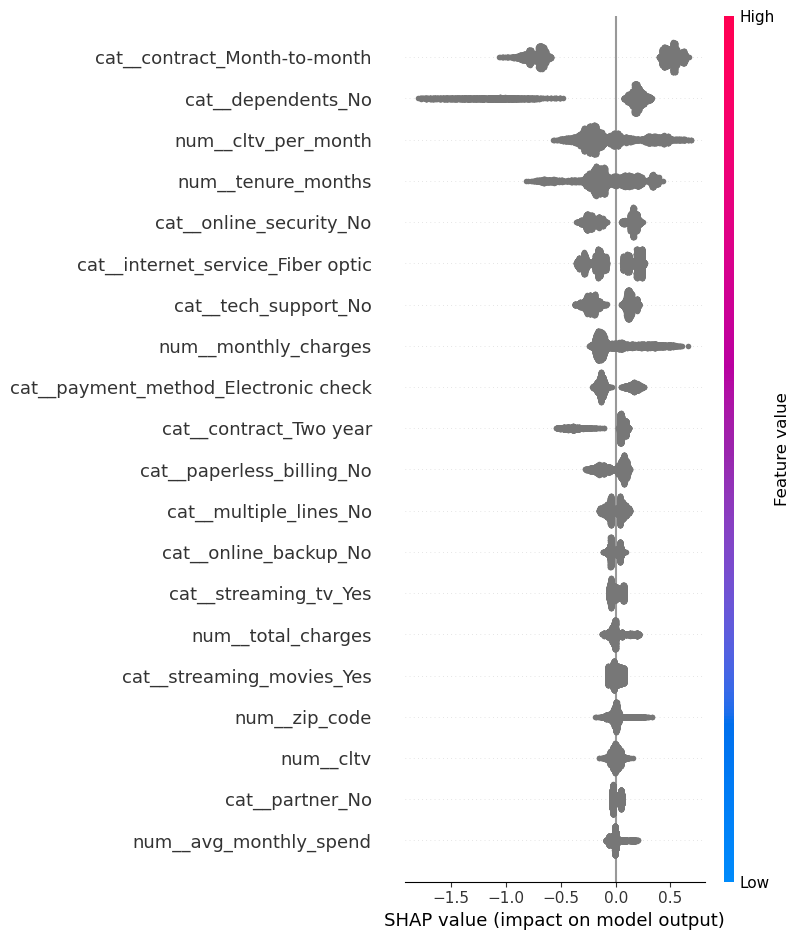

In [28]:
shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=feature_names
)